# House-Edge 🎰
### "Lever a good timing model and you'll beat the market." Will you, though — after the financing bill?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free leverage?: Busted](https://img.shields.io/badge/Free_leverage%3F-Busted-8b949e?style=flat-square)

Every leveraged-ETF and CFD timing product sells the same dream: take a clever strategy — buy the dips, dial risk up and down, sidestep the bear markets — pour leverage on it, and you beat buy-and-hold. Leverage just *amplifies* a good signal, right? We build exactly that strategy and run it on the S&P 500 back to 1990, financed two honest ways: a margin account (borrow only what's above your capital) and a CFD (the whole position carries the broker's rate). The risk control turns out to be real. The market-beating turns out to be a mirage — and the exact line where the dream dies is the **broker's markup**, not financing itself.

> 📓 **This is the plain-language layer.** The two account types, the zero-markup identity and the markup sweep are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it; the core runs on a **synthetic** market, so the real S&P numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from house_edge import data, strategy, costs, extension

# Offline synthetic control: an equity index with GARCH vol-clustering + persistent bear regimes.
# The real S&P 500 verdict is in ../docs/results.md.
price, rate, truth = data.synthetic_market(seed=30)
e = strategy.exposure(price)
print(f"synthetic control: {truth.n_days} days, {truth.n_crashes} bear regimes, seed {truth.seed}")


synthetic control: 6048 days, 9 bear regimes, seed 30


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Does the risk management work? | ✅ **Yes.** The strategy **more than halves the worst drawdown** — **-24.7%** vs buy-and-hold's **-55.7%** on the real S&P. |
| Does the *levered* version beat buy-and-hold? | 🚫 **No.** Funded at the fair bill rate it nearly *ties* (**10.1%** vs **10.6%**); at the markup a retail CFD actually charges, it makes **7.4%**. It never goes ahead. |
| Is leverage 'almost free' like the brochures imply? | ⚪ **Busted.** A CFD charges its markup on the **whole position**, not just the borrowed part — **2.65 pts/yr** at 2.5%, vs **0.66** in a margin account. Rent on money you never borrowed. |

> Desk shorthand: **Signal `REAL` · Tradability `MIRAGE` · Free leverage? `BUSTED`** — you can buy a much smoother ride, cheaply if you fund it right; you cannot buy a bigger one.

## 1 · The claim 📣

The strategy is a faithful steelman of what the timing-product sellers pitch, three good ideas stacked:

1. **Buy the dip** — lean *into* short-term weakness (a low 2-day RSI raises the target), the classic short-horizon reversal.
2. **Target volatility** — size to `target_vol / recent_vol`, so leverage gets *cut* when markets get wild instead of riding the crash down.
3. **Respect the trend** — go to cash below the 200-day average, so you're not holding a falling knife through a real bear.

Each piece is real and well-studied. The claim is that *assembled and levered*, the package beats just owning the index.

average exposure 0.70x  |  time fully in cash 29%


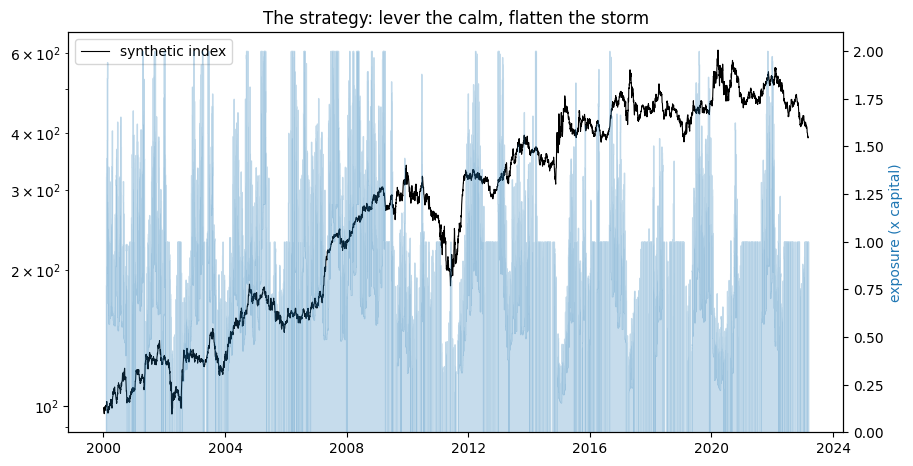

In [2]:
fig, ax = plt.subplots()
ax.plot(price.index, price.values, lw=0.8, color='black', label='synthetic index')
ax2 = ax.twinx()
ax2.fill_between(e.index, 0, e.values, color='#1f77b4', alpha=0.25, step='pre', label='target exposure')
ax2.set_ylabel('exposure (x capital)', color='#1f77b4'); ax2.set_ylim(0, 2.1)
ax.set_yscale('log'); ax.set_title('The strategy: lever the calm, flatten the storm'); ax.legend(loc='upper left')
print(f'average exposure {e.mean():.2f}x  |  time fully in cash {100*(e==0).mean():.0f}%')

## 2 · So what? 💰

If it worked, it would be the holy grail of retail trading: a rules-based way to beat the index *with the index*, just by sizing cleverly and borrowing. It's a multi-billion-dollar pitch — leveraged ETFs, CFD 'systems', vol-targeting overlays. The catch nobody puts on the slide is that leverage is *rented*, and the rent has two parts: the money-market rate (fair — everyone pays it, one way or another) and the **broker's markup on top**. The desk's question: once you pay each part honestly — and only once — what's left?

## 3 · How we'd know 🔬

Two measurements, one discipline:

1. **Does it cut risk?** Compare max-drawdown of the strategy vs buy-and-hold.
2. **Does it beat the index?** Same comparison on CAGR and Sharpe — with every Sharpe quoted *in excess of the T-bill* for both sides, so the financed book and the index are on the same footing.
3. **The discipline:** charge every dollar exactly once. A margin account borrows only the slice above 100% (idle cash earns the bill); a CFD carries the *whole* notional at bill + markup (your capital stays in bills). At a zero markup the two are identical — what differs is where the markup lands.

**Mirage line:** the levered book never out-earns buy-and-hold — and at the markups retail accounts really pay, it clearly loses.

## 4 · The teardown 🔧

### 4a · The real part — it halves the drawdown

max drawdown  strategy -27%   vs   buy & hold -44%


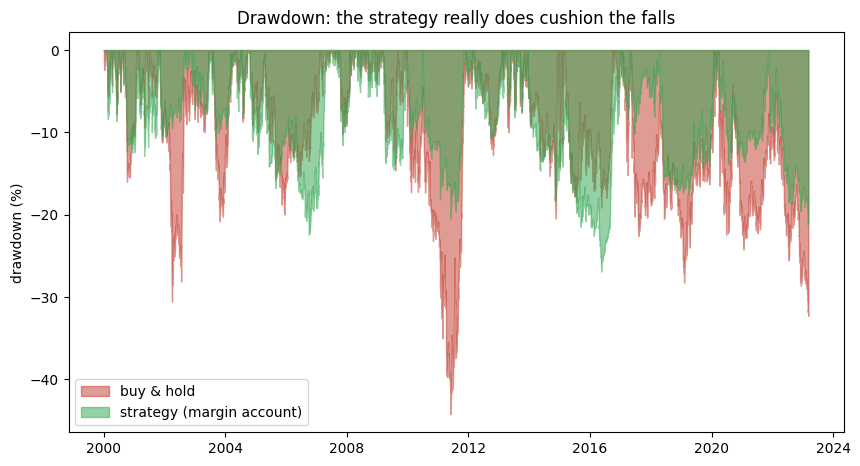

In [3]:
bh = costs.buy_and_hold(price)
marg = costs.net_returns(e, price, rate, mode='margin')   # the central case: margin @ 2.5% markup
eq_bh = (1+bh).cumprod(); eq_s = (1+marg).cumprod()
dd_bh = eq_bh/eq_bh.cummax()-1; dd_s = eq_s/eq_s.cummax()-1
fig, ax = plt.subplots()
ax.fill_between(dd_bh.index, dd_bh*100, 0, color='#c0392b', alpha=0.5, label='buy & hold')
ax.fill_between(dd_s.index, dd_s*100, 0, color='#2ea44f', alpha=0.5, label='strategy (margin account)')
ax.set_ylabel('drawdown (%)'); ax.set_title('Drawdown: the strategy really does cushion the falls'); ax.legend()
print(f"max drawdown  strategy {dd_s.min()*100:.0f}%   vs   buy & hold {dd_bh.min()*100:.0f}%")

On the real S&P 500 the gap is even starker: **-24.7%** vs **-55.7%** — a 30.9-point cut (../docs/results.md). That part of the pitch is true.

### 4b · The mirage — no out-earning, and the markup is the dial

In [4]:
flat = costs.net_returns(e, price, rate, mode='futures', markup=0.0)
cfd  = costs.net_returns(e, price, rate, mode='futures')               # markup on the WHOLE notional
for nm, r in [('buy & hold (total return)', bh), ('strategy: funded FLAT (0%)', flat),
              ('strategy: margin @ 2.5%', marg), ('strategy: CFD @ 2.5%', cfd)]:
    s = strategy.summary(r, rf=rate)
    print(f"{nm:30} CAGR {s['cagr']*100:5.1f}%   Sharpe(excess) {s['sharpe']:5.2f}   maxDD {s['max_drawdown']*100:5.0f}%")
he = costs.house_edge(e, price, rate)
print(f"\nthe broker's take at a 2.5% markup: CFD {he['house_edge_ann']*100:.2f} pts/yr vs margin "
      f"{he['margin_edge_ann']*100:.2f} -- the difference is markup charged on money you never borrowed")

buy & hold (total return)      CAGR   7.8%   Sharpe(excess)  0.28   maxDD   -44%
strategy: funded FLAT (0%)     CAGR   6.4%   Sharpe(excess)  0.22   maxDD   -27%
strategy: margin @ 2.5%        CAGR   6.1%   Sharpe(excess)  0.20   maxDD   -27%
strategy: CFD @ 2.5%           CAGR   4.5%   Sharpe(excess)  0.09   maxDD   -29%

the broker's take at a 2.5% markup: CFD 1.85 pts/yr vs margin 0.28 -- the difference is markup charged on money you never borrowed


> 🔬 **For the quants.** Same exposure path, three fundings. *Flat* (markup 0 — roughly where index futures roll) is what the brochure implicitly assumes; *margin* pays 2.5% on the borrowed slice only; *CFD* pays it on the whole notional. On the real S&P: flat **10.1%** vs the index's **10.6%** (a near-tie, at a *better* excess Sharpe 0.54 vs 0.50), margin **9.4%**, CFD **7.4%**. The CFD markup bill is **2.65 pts/yr** ≈ average exposure × markup.

## 5 · The verdict 🧾

- **Risk control is real** — drawdown cut by 30.9 points (-24.7% vs -55.7% on the S&P), Calmar doubled (0.38 vs 0.19).
- **The market-beating is a mirage** — even funded flat it ties at best (10.1% vs 10.6%); at the retail CFD markup it makes 7.4% at a clearly lower excess Sharpe (0.38 vs 0.50).
- **'Free leverage' is busted** — the CFD charges its markup on the whole position: 2.65 pts/yr vs the margin account's 0.66.

> **Signal `REAL` · Tradability `MIRAGE` · Free leverage? `BUSTED`.** What's for sale here is *insurance* — about 0.7 pts/yr in a margin account for half the drawdown — not a bigger return. The dream dies precisely at the broker's markup line.

## 6 · Could you trade it? 💸

- **Not for the advertised reason.** It never out-earns the index — not even funded at the pure bill rate. "Lever a good signal and beat the market" fails before fees even start.
- **The funding venue is the whole game.** Index futures roll near the bill: there the book nearly ties the index with **half the drawdown** — genuinely useful. A retail CFD charges 1.5–3% over the bill *on the entire position*: there the same book gives back a quarter of the market's return. Same strategy, same signal — the account type decides.
- **What it's genuinely *for*:** survival. If a −56% buy-and-hold drawdown would liquidate you (or stop you sleeping), paying ~1 pt/yr in a margin account for a −25% one is cheap insurance. That's risk management, honestly priced — not a market-beating edge.

## 7 · Going further 🚪

- **The markup sweep** (beat 7 of the quants notebook + [`../docs/results.md`](../docs/results.md)): the CAGR edge vs buy-and-hold is negative at *every* markup in *both* account types — but at markup 0 it's a 0.5-pt rounding error, and at retail CFD markups it's 2–3 pts/yr. The mirage is the markup, not the leverage.
- **Where leverage *can* pay:** on books with a genuinely higher Sharpe than the index, funded near-flat (futures), sized as a constant tilt. Test a levered *risk-parity* book vs this timing one.
- **The insurance you're buying:** is −25% instead of −56% worth ~1 pt/yr for *your* utility? That's a personal trade-off, not a universal verdict — fork the notebook and price it for your own risk aversion.

PRs welcome — add a levered constant-tilt benchmark, or a utility-based drawdown price.